## <center> **Food Delivery Time Prediction** <center>
---

### <center> **01. Data Previewing and Understanding** </center>

### Step 1.1: Imports

In [67]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = [8, 6]

# Set the warning filter to ignore FutureWarning
warnings.simplefilter(action = "ignore", category = FutureWarning)

### Load the dataset

In [68]:
df = pd.read_csv("Food_Delivery_Times.csv")

### Number of Rows and Columns

In [69]:
df.shape

(1000, 9)

### First five rows

In [70]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Last five rows

In [71]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


### Five random rows

In [72]:
df.sample(5)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
286,360,11.72,Rainy,Low,Evening,Bike,11,9.0,42
602,323,13.37,Foggy,Medium,Evening,Scooter,16,9.0,71
196,333,0.78,Clear,Medium,Morning,Bike,6,1.0,17
164,866,11.41,Windy,Medium,Afternoon,Scooter,17,4.0,68
696,611,1.27,Foggy,High,Afternoon,Bike,25,9.0,46


### Columns and their data types

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Statistical summary of the data

In [74]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Numeric columns

In [75]:
numeric_cols = df.select_dtypes(include=["number"])

for column in numeric_cols:
    print(f"- {column}")

- Order_ID
- Distance_km
- Preparation_Time_min
- Courier_Experience_yrs
- Delivery_Time_min


### Categorical columns

In [76]:
categorical_cols = df.select_dtypes(include=["object"])

for column in categorical_cols:
    print(f"- {column}")

- Weather
- Traffic_Level
- Time_of_Day
- Vehicle_Type


### Number of null values in each column

In [77]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

### Percentage of null values in each column

In [78]:
df.isnull().sum() / len(df) * 100

Order_ID                  0.0
Distance_km               0.0
Weather                   3.0
Traffic_Level             3.0
Time_of_Day               3.0
Vehicle_Type              0.0
Preparation_Time_min      0.0
Courier_Experience_yrs    3.0
Delivery_Time_min         0.0
dtype: float64

### <center> **Data Visualization** </center>
---

In [79]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Create New feature based on `Distance_km`

In [80]:
def distance(dist):
    if dist <= 6:
        return "Low distance"
    
    elif dist <= 14:
        return "Medium distance"

    else:
        return "High distance"

In [81]:
df["Distance"] = df["Distance_km"].apply(distance)

In [82]:
df[df["Distance"] == "Low distance"].tail(4)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Distance
983,100,2.60,Clear,Low,Afternoon,Bike,16,1.0,29,Low distance
984,373,2.34,Foggy,Medium,Morning,Bike,8,2.0,28,Low distance
986,459,1.60,Clear,Medium,Evening,Bike,14,8.0,24,Low distance
994,72,4.37,Clear,Medium,Evening,Scooter,6,7.0,25,Low distance


### Create New feature based on `Courier_Experience_yrs`

In [83]:
bins = [0, 2, 6, 9]

labels = ["Junior", "Mind-Level", "Senior"]

df["Experience_level"] = pd.cut(
    df["Courier_Experience_yrs"],
    bins= bins,
    labels=labels,
    include_lowest=True
)

df["Experience_level"] = df["Experience_level"].fillna(df["Experience_level"].mode()[0])

In [84]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Distance,Experience_level
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Medium distance,Junior
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,High distance,Junior
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Medium distance,Junior
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Medium distance,Junior
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,High distance,Mind-Level


### Delivery time based on Preparation time

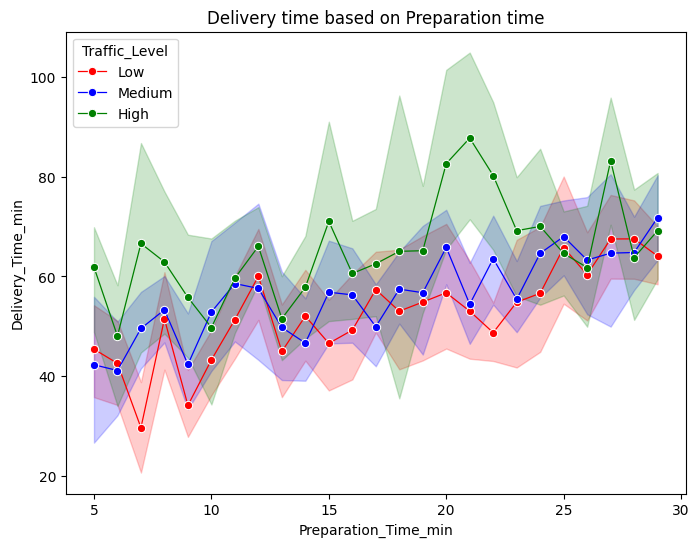

In [85]:
sns.lineplot(
    x=df["Preparation_Time_min"],
    y= df["Delivery_Time_min"],
    hue= df["Traffic_Level"],
    marker="o",
    linewidth=0.9,
    palette=["Red", "Blue", "Green"]
)

plt.title("Delivery time based on Preparation time")
plt.show()

### Delivery Time based on Traffic Level

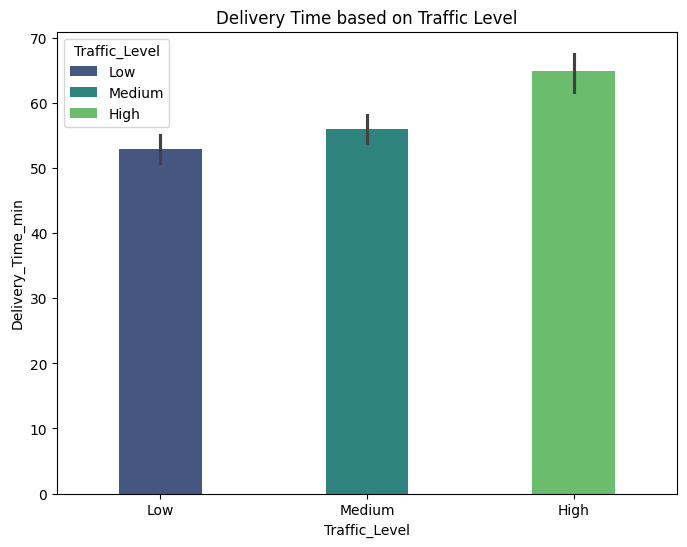

In [86]:
sns.barplot(
    x= df["Traffic_Level"],
    y= df["Delivery_Time_min"],
    hue= df["Traffic_Level"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery Time based on Traffic Level")
plt.show()

### Delivery time based on Weather

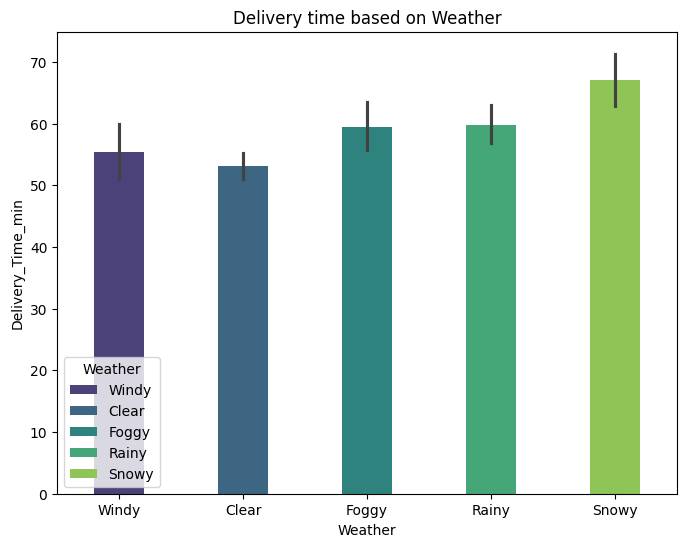

In [87]:
sns.barplot(
    x= df["Weather"],
    y= df["Delivery_Time_min"],
    hue= df["Weather"],
    palette="viridis",
    width=0.4
)

plt.title("Delivery time based on Weather")
plt.show()

### Delivery time based on Courier Experience Years

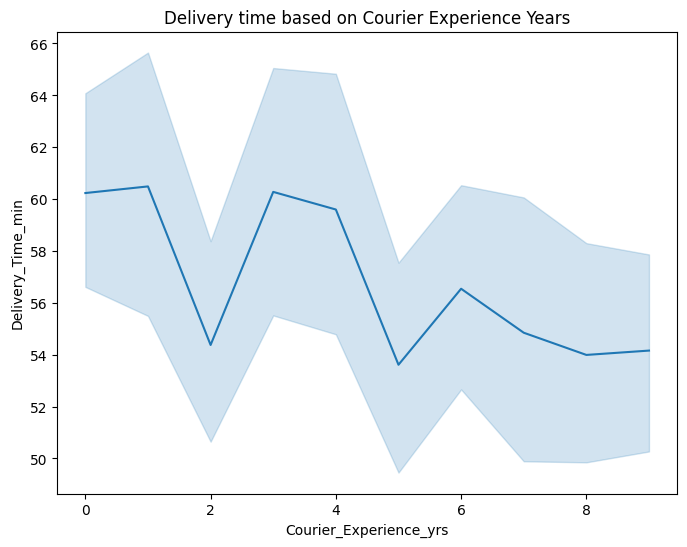

In [88]:
sns.lineplot(
    x= df["Courier_Experience_yrs"],
    y= df["Delivery_Time_min"]
)

plt.title("Delivery time based on Courier Experience Years")

plt.show()

### Delivery time based on Distance

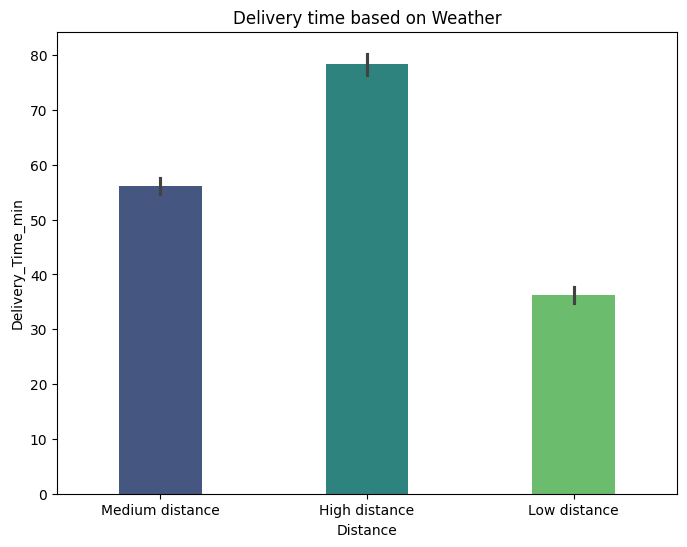

In [89]:
sns.barplot(
    x= df["Distance"],
    y= df["Delivery_Time_min"],
    hue= df["Distance"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery time based on Weather")
plt.show()

### Delivery based on Time of the day

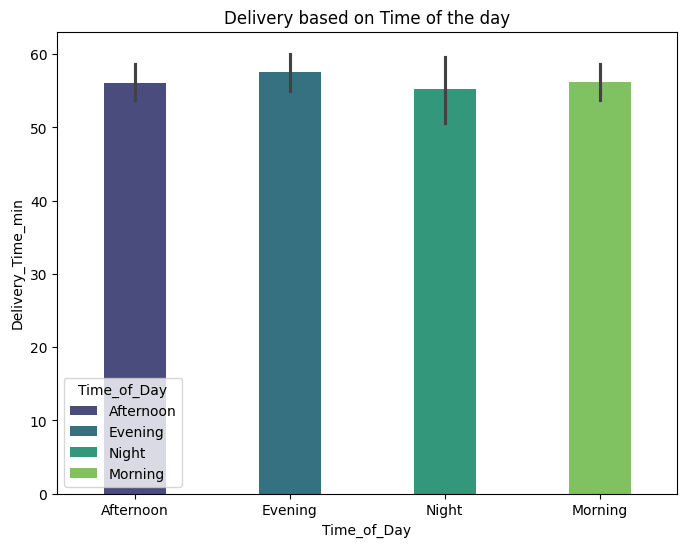

In [90]:
sns.barplot(
    x= df["Time_of_Day"],
    y= df["Delivery_Time_min"],
    hue= df["Time_of_Day"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery based on Time of the day")
plt.show()

### Delivery by Vehical Type

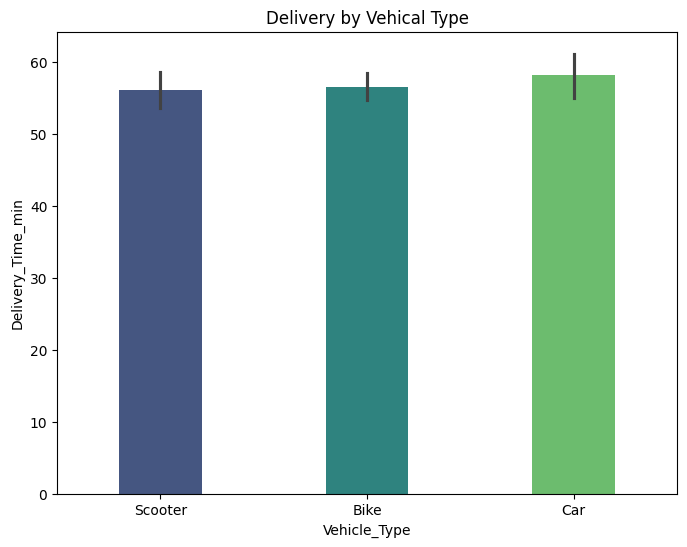

In [91]:
sns.barplot(
    x= df["Vehicle_Type"],
    y= df["Delivery_Time_min"],
    hue= df["Vehicle_Type"],
    palette="viridis",
    width=0.4
)

plt.title("Delivery by Vehical Type")
plt.show()

### Delivery time based on Experience Level

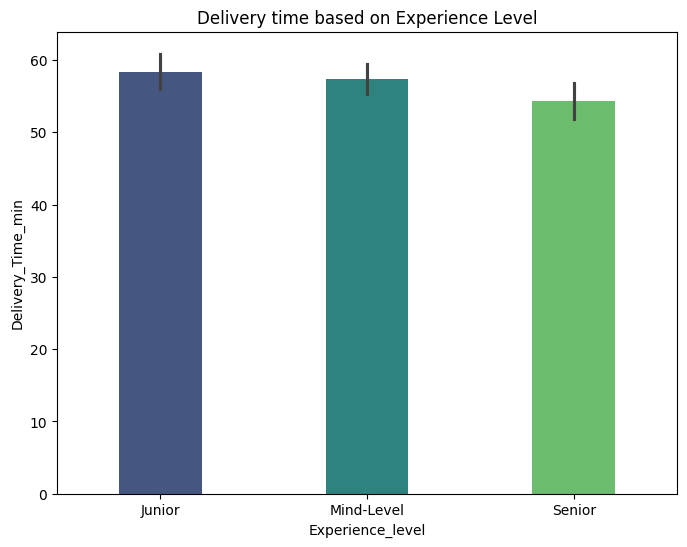

In [92]:
sns.barplot(
    x= df["Experience_level"],
    y= df["Delivery_Time_min"],
    hue= df["Experience_level"],
    palette= "viridis",
    width=0.4
)

plt.title("Delivery time based on Experience Level")

plt.show()

### Visualization of missing values

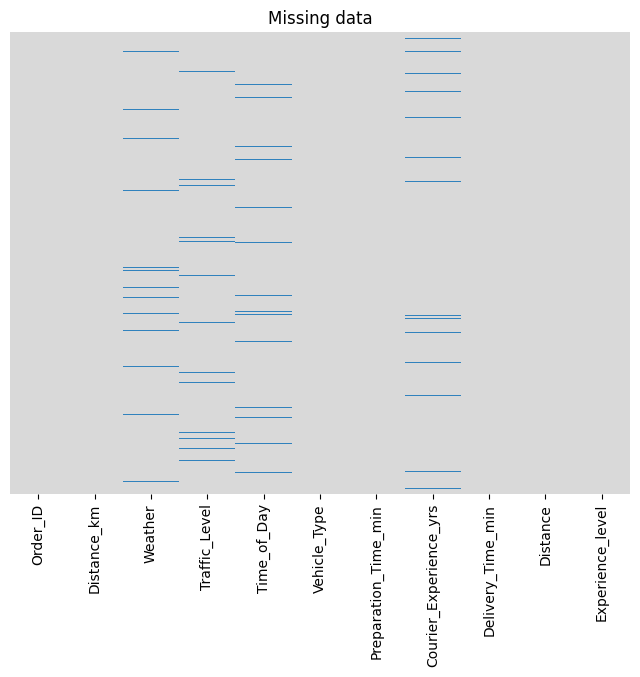

In [93]:

sns.heatmap(
    df.isnull(), 
    yticklabels=False, 
    cbar=False, 
    cmap="tab20c_r"
)

plt.title("Missing data")
plt.show()

### Duplicate values

In [94]:
df.duplicated().sum()

0

- No any duplicate value

### <center> **Data Cleaning and Preprocessing** </center>

### Remove `Order_ID`

In [95]:
df.drop("Order_ID", axis=1, inplace=True)

### Features and Target

In [96]:
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

### Training and Test sets

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_train.shape}")

X_train shape: (800, 9)
y_train shape: (800,)
X_test shape: (200, 9)
y_test shape: (800,)


In [114]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Distance,Experience_level
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Medium distance,Junior
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84,High distance,Junior
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Medium distance,Junior
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Medium distance,Junior
4,19.03,Clear,Low,Morning,Bike,16,5.0,68,High distance,Mind-Level


### Separate Numeric and Categorical features

In [139]:
numerical_features = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]
categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type",
    "Distance",
    "Experience_level"
]

### Build Preprocessing Pipeline

In [140]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

### Column Transformer

In [141]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features,
            
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### Create LinearRegression Pipeline

In [142]:
pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regression",
            RandomForestRegressor(
                n_estimators=345
            )
        )
    ]
)


model = pipeline.fit(X_train, y_train)

### Make Predictions

In [143]:
y_pred = model.predict(X_test)
print(y_pred)

[33.44057971 64.73913043 42.1884058  46.53623188 77.68115942 35.32753623
 66.66666667 33.83768116 32.68985507 77.7826087  74.93333333 62.
 36.34782609 75.05507246 89.2057971  84.82898551 29.76811594 66.79710145
 48.9942029  59.21449275 78.73333333 30.0173913  72.67246377 74.3826087
 62.51594203 33.33913043 79.16811594 25.06956522 51.1826087  60.37101449
 67.74202899 20.11014493 56.59130435 39.36521739 73.80289855 16.22028986
 65.09275362 56.08115942 44.8        78.87826087 75.24637681 32.52753623
 76.86956522 66.01449275 41.08695652 19.44347826 91.27826087 79.28405797
 83.14202899 29.0115942  71.60869565 57.77681159 40.6        80.31594203
 53.76811594 52.88115942 78.04057971 79.50144928 62.84637681 89.06956522
 53.18550725 35.79710145 50.76231884 46.49275362 50.29275362 57.61449275
 70.50434783 91.35942029 64.03188406 56.97101449 79.63768116 38.71594203
 85.77101449 26.46376812 64.8        62.30144928 40.43768116 42.02028986
 50.62608696 30.96811594 60.25217391 72.31304348 63.56231884

### Compare Actual and Predicted values

In [144]:
# Combine actual and predicted values side by side
results = np.column_stack((y_test, y_pred))

# Printing the results
print("Actual Values  |  Predicted Values")
print("-----------------------------")
for actual, predicted in results:
    print(f"{actual:14.2f} |  {predicted:12.2f}")

Actual Values  |  Predicted Values
-----------------------------
         32.00 |         33.44
         68.00 |         64.74
         39.00 |         42.19
         44.00 |         46.54
         85.00 |         77.68
         31.00 |         35.33
         77.00 |         66.67
         33.00 |         33.84
         90.00 |         32.69
         91.00 |         77.78
         64.00 |         74.93
         69.00 |         62.00
         38.00 |         36.35
         91.00 |         75.06
         79.00 |         89.21
         74.00 |         84.83
         26.00 |         29.77
         77.00 |         66.80
         38.00 |         48.99
         63.00 |         59.21
         87.00 |         78.73
         24.00 |         30.02
         88.00 |         72.67
         77.00 |         74.38
         57.00 |         62.52
         30.00 |         33.34
         94.00 |         79.17
         24.00 |         25.07
         51.00 |         51.18
         71.00 |         60.37
     

### Evaluate model

In [145]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

Mean Squared Error: 91.46943595883218
Mean Absolute Error: 6.756565217391304
R2 Score: 0.7959305417554752


### Compare Scores

In [146]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print(f"Training: {r2_train}")
print(f"Test: {r2_test}")

Training: 0.9568098381732032
Test: 0.7959305417554752
